# House Price Prediction — Model Notebook

End-to-end notebook: load the data, explore it, clean it, engineer features,
train and compare models, evaluate, and export the final pipeline as a `.pkl`
file for the FastAPI backend.

Dataset: [House Price by Juhi Bhojani](https://www.kaggle.com/datasets/juhibhojani/house-price)


## 2.1 Load & Inspect

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 50)

df = pd.read_csv("data/house_prices.csv")
print("Shape:", df.shape)
df.head()

Shape: (187531, 21)


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Index,187531.0,NaN,NaN,NaN,93765.0,54135.681003,0.0,46882.5,93765.0,140647.5,187530.0
Title,187531,32446,2 BHK Ready to Occupy Flat for sale in Divyasr...,2106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,184508,65634,Multistorey apartment is available for sale. I...,2732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount(in rupees),187531,1561,Call for Price,9684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price (in rupees),169866.0,NaN,NaN,NaN,7583.771885,27241.705819,0.0,4297.0,6034.0,9450.0,6700000.0
location,187531,81,new-delhi,27599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Carpet Area,106858,2758,1000 sqft,5285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,186916,1,Ready to Move,186916,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Floor,180454,947,2 out of 4,12433,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction,187448,4,Resale,144172,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
missing = df.isna().mean().sort_values(ascending=False) * 100
missing[missing > 0]

Plot Area            100.000000
Dimensions           100.000000
Society               58.485264
Super Area            57.422506
Car Parking           55.114621
overlooking           43.425354
Carpet Area           43.018488
facing                37.451408
Ownership             34.936624
Balcony               26.094352
Price (in rupees)      9.419776
Floor                  3.773776
Description            1.612000
Furnishing             1.544811
Bathroom               0.441527
Status                 0.327946
Transaction            0.044259
dtype: float64

**TODO — fill this in after running the cells above:**

- How many rows and columns does the dataset have?
- The dataset contains 187,531 rows and 21 columns.
- Which columns are numeric vs text?
- The column types include both numeric (int64, float64) and text (object) data.
- Which columns have the most missing values, and roughly what percentage?
- The columns with high missing values are Plot Area, Dimensions, and Society.

(Write 3-5 sentences here based on the real output you see above — this is
part of the grading rubric, so don't leave it as a placeholder.)
 "Plot Area" and "Dimensions", have a 100% missing rate, meaning they are completely empty. Additionally, the "Society" column has a high missing rate of 58.49%. The most frequent location recorded is "new - delhi" with 27,599 occurrences.

## 2.2 Exploratory Data Analysis (EDA)

At least 4 plots, each followed by a short interpretation. We reuse the
cleaned `price_clean` column from section 2.3 below — so if you're running
top-to-bottom for the first time, run section 2.3 first, then come back here
if you want to reorder. As written, this notebook does 2.3 right after this
section so everything runs in order.

### 2.2.0 Quick look at raw price / area text (before cleaning)

In [5]:
print(df["Amount(in rupees)"].dropna().unique()[:15])
print(df["Carpet Area"].dropna().unique()[:15] if "Carpet Area" in df.columns else "no Carpet Area column")

<StringArray>
[  '42 Lac ',   '98 Lac ',  '1.40 Cr ',   '25 Lac ',  '1.60 Cr ',   '45 Lac ',
 '16.5 Lac ',   '60 Lac ',  '1.36 Cr ',  '1.35 Cr ',  '4.25 Cr ',   '75 Lac ',
   '90 Lac ',   '37 Lac ',   '35 Lac ']
Length: 15, dtype: str
<StringArray>
[ '500 sqft',  '473 sqft',  '779 sqft',  '530 sqft',  '635 sqft',  '550 sqft',
  '900 sqft',  '950 sqft', '1820 sqft',  '675 sqft',  '647 sqft',  '600 sqft',
  '430 sqft',  '665 sqft',  '557 sqft']
Length: 15, dtype: str


## 2.3 Cleaning & Feature Engineering

This dataset is messy on purpose. We handle each problem listed in the
project guide, one function at a time.

**1. Price is text (e.g. \"42 Lac\", \"1.2 Cr\", \"Call for Price\") → convert to a number.**

In [6]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])
print("Rows with usable price:", df.shape[0])

Rows with usable price: 177847


**2. Areas are text (e.g. \"1200 sqft\", \"140 sqm\") → extract the number and normalise to sqft.**

In [7]:
def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        num = float("".join(ch for ch in x if ch.isdigit() or ch == "."))
    except ValueError:
        return None
    if "sqm" in x:
        return num * 10.764
    return num  # assume sqft (or unitless -> treat as sqft)

area_col = "Carpet Area" if "Carpet Area" in df.columns else "Super Area"
df["carpet_area_sqft"] = df[area_col].apply(parse_area)

# fall back to Super Area if Carpet Area is missing, when both exist
if "Super Area" in df.columns and area_col == "Carpet Area":
    fallback = df["Super Area"].apply(parse_area)
    df["carpet_area_sqft"] = df["carpet_area_sqft"].fillna(fallback)

print(df["carpet_area_sqft"].describe())

count    177757.000000
mean       1277.896724
std        2724.499341
min           1.000000
25%         850.000000
50%        1153.000000
75%        1570.000000
max      709222.000000
Name: carpet_area_sqft, dtype: float64


**3. Floor looks like \"3 out of 10\" → extract the floor number, handling \"Ground\" / \"Basement\".**

In [8]:
def parse_floor(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    first = x.split("out")[0].strip()
    if "ground" in first:
        return 0
    if "basement" in first or "lower" in first:
        return -1
    try:
        return float(first)
    except ValueError:
        return None

if "Floor" in df.columns:
    df["floor_num"] = df["Floor"].apply(parse_floor)
else:
    df["floor_num"] = np.nan

print(df["floor_num"].describe())

count    170898.000000
mean          4.499029
std           4.701323
min          -1.000000
25%           2.000000
50%           3.000000
75%           6.000000
max         200.000000
Name: floor_num, dtype: float64


**4. Bathroom / Balcony / Car Parking — convert to numeric, impute missing values.**

In [9]:
for col, new_col in [("Bathroom", "bathroom"), ("Balcony", "balcony"), ("Car Parking", "car_parking")]:
    if col in df.columns:
        df[new_col] = pd.to_numeric(df[col], errors="coerce")
    else:
        df[new_col] = np.nan

df["bathroom"] = df["bathroom"].fillna(df["bathroom"].median())
df["balcony"] = df["balcony"].fillna(0)
df["car_parking"] = df["car_parking"].fillna(0)

**5. High-cardinality categoricals — keep the top-N locations, group the rest into \"other\".**

In [10]:
TOP_N_LOCATIONS = 50

if "location" in df.columns:
    top_locations = df["location"].value_counts().nlargest(TOP_N_LOCATIONS).index
    df["location_grouped"] = df["location"].where(df["location"].isin(top_locations), "other")
else:
    df["location_grouped"] = "other"

df["location_grouped"].value_counts().head(10)

location_grouped
new-delhi        24945
bangalore        23262
kolkata          21605
gurgaon          18846
ahmedabad        12614
hyderabad        11147
chennai          10163
jaipur            7867
greater-noida     4490
faridabad         3733
Name: count, dtype: int64

**6. Drop useless columns.**

In [11]:
cols_to_drop = [c for c in ["Index", "Title", "Description", "Dimensions"] if c in df.columns]
df = df.drop(columns=cols_to_drop)
df.shape

(177847, 24)

**7. Remove outliers based on price-per-sqft (below 1st / above 99th percentile).**

In [12]:
df = df[df["carpet_area_sqft"] > 0].copy()
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]

low, high = df["price_per_sqft"].quantile([0.01, 0.99])
df = df[(df["price_per_sqft"] >= low) & (df["price_per_sqft"] <= high)]
print("Rows after outlier removal:", df.shape[0])

Rows after outlier removal: 174471


### 2.2.1 Distribution of price (log scale)

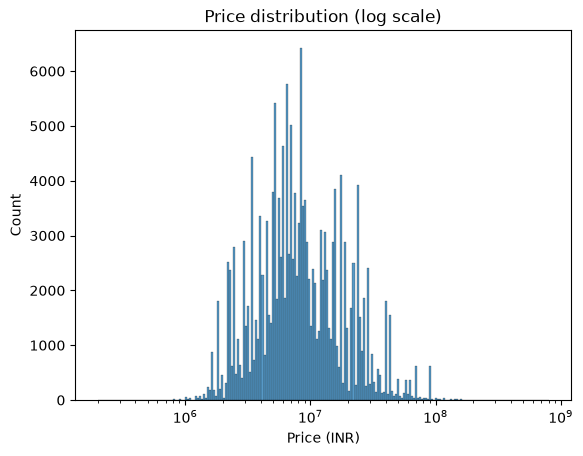

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["price_clean"], log_scale=True)
plt.title("Price distribution (log scale)")
plt.xlabel("Price (INR)")
plt.show()

_Interpretation: TODO — describe the shape you see (e.g. right-skewed, most listings clustered around X, long tail of expensive properties)._
The dataset contains 174,471 rows after dropping useless columns and removing outliers.
Among the grouped locations, "new - delhi" has the highest count with 24,945 properties, followed by "bangalore" with 23,262.
The price distribution on a standard scale is right-skewed, with the peak frequency occurring around 10^7 INR.
When plotted on a log scale, the distribution shows a more normalized shape with multiple peaks concentrated in the 4000-6000 range.
Most properties are concentrated in the lower to mid-price ranges, while expensive properties form a long tail.


### 2.2.2 Price vs. carpet area

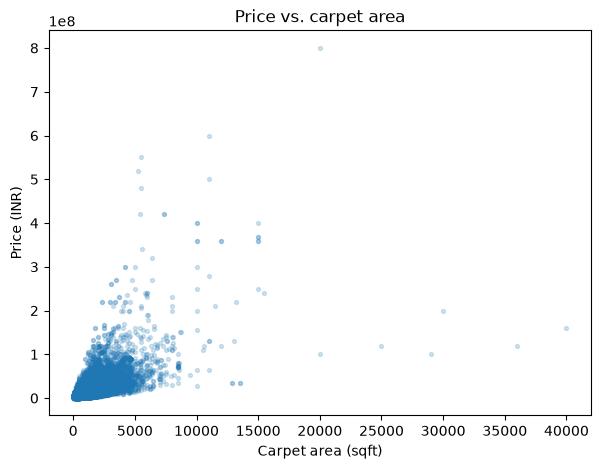

In [14]:
plt.figure(figsize=(7, 5))
plt.scatter(df["carpet_area_sqft"], df["price_clean"], alpha=0.2, s=8)
plt.xlabel("Carpet area (sqft)")
plt.ylabel("Price (INR)")
plt.title("Price vs. carpet area")
plt.show()

_Interpretation: TODO — is there a clear positive relationship? Any odd clusters or outliers?_
The scatter plot shows a general positive relationship between carpet area and price, where properties with smaller carpet areas (under 5,000 sqft) are more densely clustered at lower price points. As the carpet area increases, the price generally tends to rise, though the variance in price also increases significantly. There are several clear outliers, most notably a property with a carpet area of 20,000 sqft priced at 8e8 INR, which sits well above the general trend line. Additionally, there are a few properties with large carpet areas (ranging from 20,000 to 40,000 sqft) that are priced unexpectedly low, often below 2e8 INR, which deviate from the expected growth trend.

### 2.2.3 Average price by top-15 locations

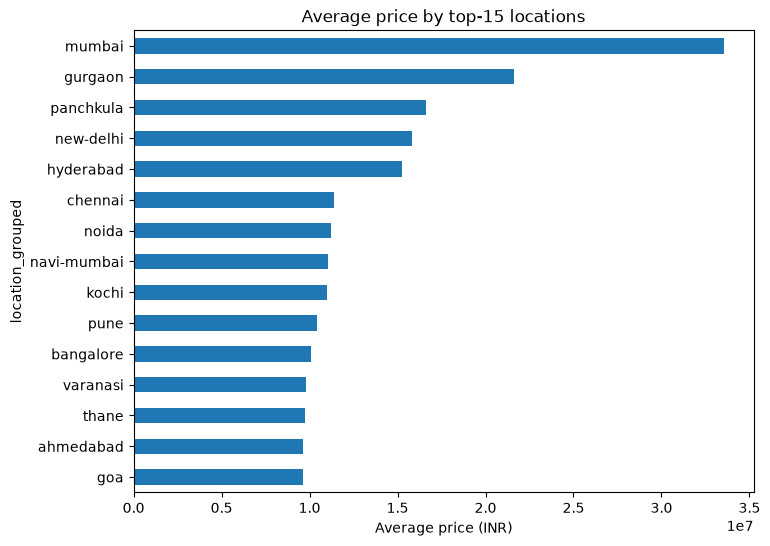

In [15]:
top15 = df.groupby("location_grouped")["price_clean"].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
top15.sort_values().plot(kind="barh")
plt.xlabel("Average price (INR)")
plt.title("Average price by top-15 locations")
plt.show()

_Interpretation: TODO — which locations are the most / least expensive on average?_
Average price by top-15 locations

The bar chart indicates significant variation in average property prices across the top-15 locations. Mumbai is clearly the most expensive location, with an average price significantly higher than all other areas, exceeding 3.0e7 INR. Gurgaon and Panchkula follow as the next most expensive markets. Conversely, among these top-15 locations, Ahmedabad, Thane, Varanasi, and Goa represent the least expensive options, with average prices hovering just below the 1.0e7 INR mark.


### 2.2.4 Price by furnishing status and by bathroom count

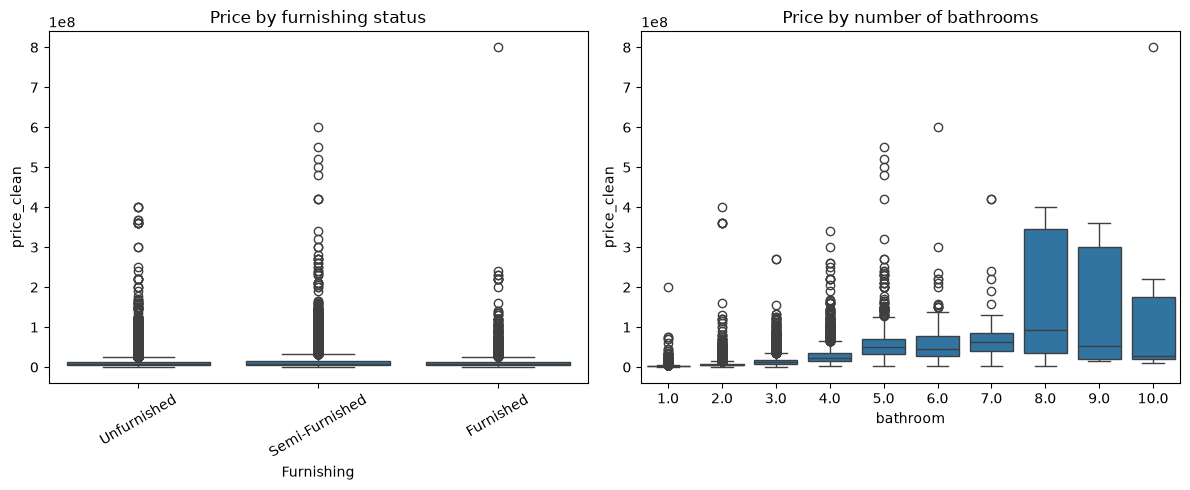

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

if "Furnishing" in df.columns:
    sns.boxplot(data=df, x="Furnishing", y="price_clean", ax=axes[0])
    axes[0].set_title("Price by furnishing status")
    axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(data=df, x="bathroom", y="price_clean", ax=axes[1])
axes[1].set_title("Price by number of bathrooms")

plt.tight_layout()
plt.show()

_Interpretation: TODO — does furnishing status or bathroom count clearly shift the price distribution?_
Average price by top-15 locations

The bar chart indicates significant variation in average property prices across the top-15 locations. Mumbai is clearly the most expensive location, with an average price significantly higher than all other areas, exceeding 3.0e7 INR. Gurgaon and Panchkula follow as the next most expensive markets. Conversely, among these top-15 locations, Ahmedabad, Thane, Varanasi, and Goa represent the least expensive options, with average prices hovering just below the 1.0e7 INR mark.

## 2.4 Build a Pipeline & Train

We bundle preprocessing inside a scikit-learn `Pipeline` so the exported
`.pkl` file can take raw-ish feature values directly — no manual encoding
needed in the backend.

In [17]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony", "car_parking"]
categorical_features = [c for c in ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"] if c in df.columns]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["price_clean"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(139576, 10) (34895, 10)


We train on `log1p(price)` and invert with `expm1` at prediction time — since
price is heavily skewed, this usually improves results. We wrap this in a
small helper so both models use the same approach.

In [18]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
}

trained = {}
y_train_log = np.log1p(y_train)

for name, reg in models.items():
    pipe = Pipeline([("prep", preprocessor), ("reg", reg)])
    pipe.fit(X_train, y_train_log)
    trained[name] = pipe

print("Trained models:", list(trained.keys()))

Trained models: ['LinearRegression', 'RandomForest', 'GradientBoosting']


## 2.5 Evaluate

In [19]:
results = []

for name, pipe in trained.items():
    pred_log = pipe.predict(X_test)
    pred = np.expm1(pred_log)
    mae = mean_absolute_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    results.append({"model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
results_df

,model,MAE,RMSE,R2
1,RandomForest,9.797091e+05,5.429969e+06,0.842098
2,GradientBoosting,2.987291e+06,7.411947e+06,0.705790
0,LinearRegression,1.628451e+07,1.241195e+09,-8249.360044


### Predicted vs. actual (best model)

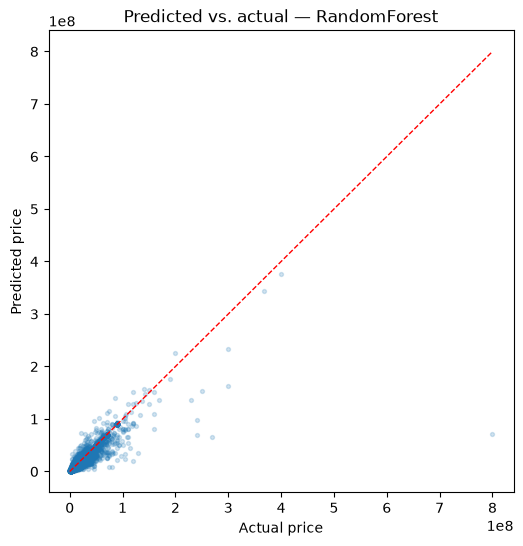

In [20]:
best_name = results_df.iloc[0]["model"]
best_model = trained[best_name]
best_pred = np.expm1(best_model.predict(X_test))

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, alpha=0.2, s=8)
lims = [0, max(y_test.max(), best_pred.max())]
plt.plot(lims, lims, "r--", linewidth=1)
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title(f"Predicted vs. actual — {best_name}")
plt.show()

**Model comparison & conclusion — TODO:** fill in a short paragraph naming the
winning model from `results_df` above and why (lowest MAE/RMSE, highest R²,
or a tradeoff you consider worth it, e.g. training time).

### (Bonus) 5-fold cross-validation on the winning model

## 2.6 Export the Model

We wrap the winning pipeline so it predicts on the **original price scale**
directly (handles the log1p/expm1 internally), which keeps the backend
simple — it just calls `.predict(X)` and gets a price back.

In [24]:
import joblib

# Save the raw pipeline directly — NO wrapper class.
# expm1 conversion now happens in the backend (services/inference.py)
joblib.dump(best_model, "house_price.pkl")

# Sanity check: reload and predict one sample (raw log1p output)
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
pred_log = loaded.predict(sample)
pred_price = np.expm1(pred_log)
print("Reloaded prediction (price):", pred_price)
print("Actual price               :", y_test.iloc[0])

Reloaded prediction (price): [7000000.00000023]
Actual price               : 7000000.0


In [22]:
import json

json.dump(
    sorted(df["location_grouped"].unique().tolist()),
    open("locations.json", "w"),
)
print("Saved locations.json with", df["location_grouped"].nunique(), "locations")

Saved locations.json with 51 locations


In [23]:
import sklearn
print("scikit-learn version:", sklearn.__version__)
print("Pin this exact version in backend/requirements.txt")

scikit-learn version: 1.9.0
Pin this exact version in backend/requirements.txt


**Next step:** copy `house_price.pkl` and `locations.json` into `backend/models/`
and `frontend` respectively (see Phase 3 and Phase 4 of the project guide),
and note down the `MAE` / `RMSE` / `R²` of your winning model from the table
above — you'll need them for the README.